Contribution fournie par Théodore Cournoyer et Philippe Dornoy


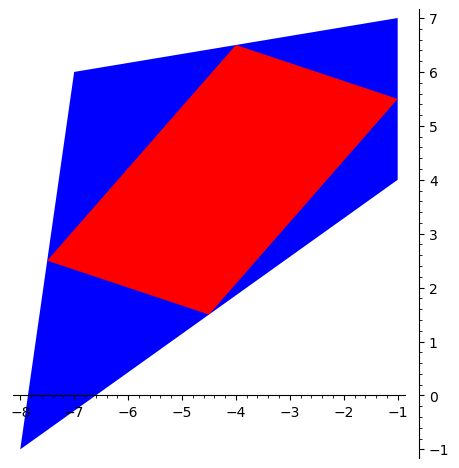

In [3]:
#Le fonctionnement global de ce programme est de filtrer les quadrilatères non désirés en vérifiant certaines charactéristiques
#Les quadrilatères croisées (dont les points sont liés dans le mauvais ordre) n'ont pas une somme d'angles internes égales à 2Pi
#Les quadrilatères avec des points identiques onts des vecteurs nuls parmi leurs cotés
#Les quadrilatères avec des côtés continus (des vecteurs parallèles bout à bout) ont un cosinus d'angle entre eux de 1 ou -1
#Les quadrilatères non-convexes peuvent fonctionner dans le cadre de cet exercice, mais sont filtrés avec les quadrilatères croisées puisque la formule renvoie toujours l'angle le plus petit entre deux vecteurs et à cause de l'angle supérieur à Pi radians, la somme des angles internes n'est plus égale à 2Pi

#On essaie des combinaisons de points jusqu'à ce qu'on obtienne un quadrilatère valide
valide = False
while not valide:
    
    #Définition des points du quadrilatère ABCD dans la liste de points
    A=vector([ZZ.random_element(-8,8),ZZ.random_element(-8,8)])
    B=vector([ZZ.random_element(-8,8),ZZ.random_element(-8,8)])
    C=vector([ZZ.random_element(-8,8),ZZ.random_element(-8,8)])
    D=vector([ZZ.random_element(-8,8),ZZ.random_element(-8,8)])    
    points = [A, B, C, D]
    
    #Initialisation de la variable qui comptera la somme des angles
    somme_angles = 0

    #Pour chaque point dans la liste, on trouve le vecteur qui le relie aux deux points voisins (les côtés)
    for i in range(4) :
        
        #Le point central
        ot = points[i]
        
        #Les deux points voisins
        p1 = points[i-3]
        p2 = points[i-1]
        
        #Les vecteurs représentant les cotés du quadrilatère
        p1prime = vector([p1[0]-ot[0], p1[1]-ot[1]])
        p2prime = vector([p2[0]-ot[0], p2[1]-ot[1]])
        
        #Vérifier la présence de vecteurs nuls
        if p1prime.norm() == 0 or p2prime.norm() == 0:
            break
            
        #Calcul du cosinus
        cosinus = (p1prime.dot_product(p2prime)) / (p1prime.norm() * p2prime.norm())

        #Vérifier la présence de côtés continus
        if cosinus >= 1 or cosinus <= -1:
            break
        
        #Calcul de l'angle entre les vecteurs
        teta = arccos(cosinus)
        
        #On ajoute la valeur de l'angle à la somme totale
        somme_angles += teta
        
        #Vérifier la présence de quadrilatère croisé ou non-convexe"
        if i==3 and somme_angles < 2*pi:
            if i==3:
                break
        #Si le quadrilatère est conforme, on brise la boucle initiale en inversant la variable 'valide'      
        elif i==3 and teta<pi:
            valide = True

#Définition des points milieux
M=A+(B-A)/2
N=B+(C-B)/2
P=C+(D-C)/2
Q=D+(A-D)/2

#Illustration des polygones
polygon([A,B,C,D])+polygon([M,N,P,Q],color="red")

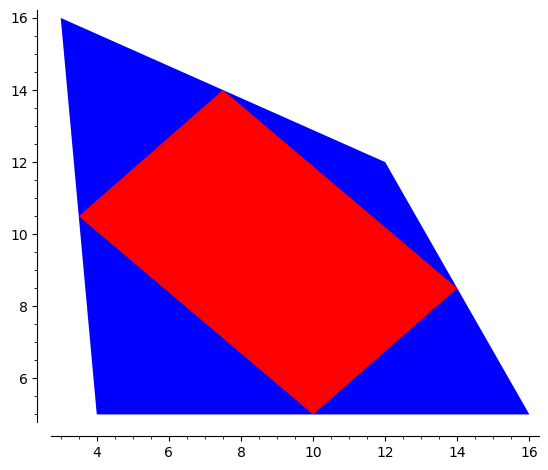

In [6]:
#On tasse le centre des divisions pour rester dans le premier quadrant du plan cartésien
x = ZZ.random_element(8,16)
y = ZZ.random_element(8,16)

#Définition des points du quadrilatère ABCD en restreignant chaque point dans un quandrant local de 8x8
#On a donc l'avantage de conserver les polygones non convexe, au prix de laisser passer ceux au cotés continus
A=vector([ZZ.random_element(x,8+y),ZZ.random_element(x,8+y)])
B=vector([ZZ.random_element(x,8+y),ZZ.random_element(x-8,y)])
C=vector([ZZ.random_element(x-8,y),ZZ.random_element(x-8,y)])
D=vector([ZZ.random_element(x-8,y),ZZ.random_element(x,8+y)])
#Définition des points milieux
M=A+(B-A)/2
N=B+(C-B)/2
P=C+(D-C)/2
Q=D+(A-D)/2
#Illustration des polygones
polygon([A,B,C,D])+polygon([M,N,P,Q],color="red")